# Figure 1 — Study setup and conceptual framework

**Target**: npj Urban Sustainability submission (Helene + Milton mobility paper).

**Three panels, generated as separate files** so you can compose them externally (Illustrator / Inkscape / Affinity / PowerPoint):
- **(a)** Map: Helene and Milton tracks, 50-mile affected envelopes, affected counties.
- **(b)** Schematic: 4-D mobility tensor → 6 categories → within / inflow / outflow at regional vs. local scales.
- **(c)** Worked example time series for the category selected in `EXAMPLE` (default: Milton · Inflow · Retail & Leisure).

**Data sources** (all pre-computed, no analysis re-run):
- Affected counties — `results/{helene,milton}/counties_geoid_cut_50.txt`
- Regional baselines — `results/regional_level/{helene,milton}/baseline_{flow}_{Category}.csv`
- Recovery metrics — `results/regional_level/regional_metrics_summary.csv`
- Hurricane tracks — `../../hurricane_oct/data/storm_track/{helene,milton}_storm_track.shp`
- County polygons — `../../hurricane_oct/data/county_geo/tl_2023_us_county/`

**Outputs** (six files — vector PDF + 300 dpi PNG for each panel) in `results/npj_figures/`:
- `figure1a_map.{pdf,png}`
- `figure1b_schematic.{pdf,png}`
- `figure1c_worked_example.{pdf,png}`

**Note**: Utilities category is excluded per submission scope. Panel-letter labels (`a`, `b`, `c`) are drawn into each panel for convenience — remove the `ax.text(..., 'a', ...)` line in each panel function if you'd rather add them during external layout.

In [1]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from matplotlib.dates import DateFormatter, DayLocator
from shapely.geometry import LineString
from shapely.ops import unary_union

warnings.filterwarnings('ignore')

# npj Urban Sustainability print-ready formatting
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

In [2]:
# ── Project path resolution ──────────────────────────────────────────
def find_project_root(start: pathlib.Path) -> pathlib.Path:
    sentinel = pathlib.Path('results') / 'regional_level' / 'regional_metrics_summary.csv'
    for p in [start, *start.parents]:
        if (p / sentinel).exists():
            return p
    raise FileNotFoundError(
        f'Could not locate project root containing {sentinel} (started from {start}).'
    )

NOTEBOOK_DIR = pathlib.Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
RESULTS = PROJECT_ROOT / 'results'

# External geo data (sibling project)
HURRICANE_OCT_DATA = PROJECT_ROOT.parent / 'hurricane_oct' / 'data'
COUNTY_SHP = HURRICANE_OCT_DATA / 'county_geo' / 'tl_2023_us_county' / 'tl_2023_us_county.shp'
TRACK_SHP = {
    'helene': HURRICANE_OCT_DATA / 'storm_track' / 'helene_storm_track.shp',
    'milton': HURRICANE_OCT_DATA / 'storm_track' / 'milton_storm_track.shp',
}

OUT_DIR = RESULTS / 'npj_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'RESULTS      : {RESULTS}')
print(f'COUNTY_SHP   : exists={COUNTY_SHP.exists()}')
print(f'TRACK_SHP    : helene={TRACK_SHP["helene"].exists()}, milton={TRACK_SHP["milton"].exists()}')
print(f'OUT_DIR      : {OUT_DIR}')

PROJECT_ROOT : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category
RESULTS      : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results
COUNTY_SHP   : exists=True
TRACK_SHP    : helene=True, milton=True
OUT_DIR      : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures


In [8]:
# ── Configuration ─────────────────────────────────────────────────────
HURRICANES = {
    'helene': {
        'label': 'Helene',
        'landing': pd.Timestamp('2024-09-26'),
        'color': '#1f77b4',
        'fill':  '#bbd6e8',
        'counties_file': RESULTS / 'helene' / 'counties_geoid_cut_50.txt',
    },
    'milton': {
        'label': 'Milton',
        'landing': pd.Timestamp('2024-10-09'),
        'color': '#d62728',
        'fill':  '#f6c0bf',
        'counties_file': RESULTS / 'milton' / 'counties_geoid_cut_50.txt',
    },
}

# 6 mobility categories (Utilities excluded for npj submission)
CATEGORIES = [
    'Travel',
    'Work & Professional',
    'Health',
    'Education',
    'Retail & Leisure',
    'Urban Government',
]

# Okabe-Ito colorblind-safe palette
CATEGORY_COLORS = {
    'Travel'             : '#0072B2',
    'Work & Professional': '#E69F00',
    'Health'             : '#009E73',
    'Education'          : '#CC79A7',
    'Retail & Leisure'   : '#56B4E9',
    'Urban Government'   : '#D55E00',
}

# Worked example for panel (c) — change these to swap the example
EXAMPLE = {
    'hurricane': 'milton',
    'flow_type': 'within',
    'category':  'Retail & Leisure',
}

def category_to_filename(cat: str) -> str:
    return cat.replace(' & ', '_and_').replace(' ', '_')

def save_panel(fig, stem):
    pdf_path = OUT_DIR / f'{stem}.pdf'
    png_path = OUT_DIR / f'{stem}.png'
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'  saved \u2192 {pdf_path}')
    print(f'  saved \u2192 {png_path}')

## Panel (a) — Affected counties + hurricane tracks

Saves `figure1a_map.{pdf,png}`.

  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure1a_map.pdf
  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure1a_map.png


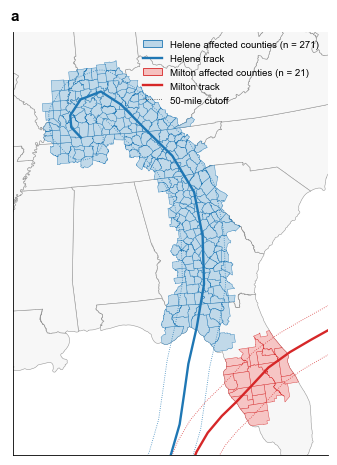

In [5]:
def panel_a_map(ax):
    """Plot affected counties for Helene + Milton with both tracks and 50-mi envelope."""
    counties = gpd.read_file(COUNTY_SHP).to_crs(epsg=5070)
    counties['GEOID'] = counties['GEOID'].astype(str)

    # Affected counties per hurricane
    affected = {}
    for hkey, hmeta in HURRICANES.items():
        with open(hmeta['counties_file']) as f:
            geoids = {g.strip().zfill(5) for g in f if g.strip()}
        affected[hkey] = counties[counties['GEOID'].isin(geoids)].copy()

    # Hurricane tracks as single LineStrings
    tracks = {}
    for hkey in HURRICANES:
        tg = gpd.read_file(TRACK_SHP[hkey]).to_crs(epsg=5070)
        geom0 = tg.geometry.iloc[0]
        if geom0.geom_type == 'Point':
            tracks[hkey] = LineString(tg.geometry.tolist())
        else:
            tracks[hkey] = unary_union(tg.geometry.tolist())

    # 50-mile (80.47 km) buffer envelopes around tracks
    envelopes = {h: tracks[h].buffer(50 * 1609.34) for h in HURRICANES}

    # Extent from affected counties (with padding)
    all_affected = pd.concat([affected[h] for h in HURRICANES])
    minx, miny, maxx, maxy = all_affected.total_bounds
    pad = 0.08 * max(maxx - minx, maxy - miny)

    # Background — state outlines (dissolve counties by STATEFP)
    states = counties.dissolve(by='STATEFP')
    states.plot(ax=ax, facecolor='#f7f7f7', edgecolor='#999999', linewidth=0.4)

    # 50-mile envelope outlines
    for hkey, hmeta in HURRICANES.items():
        env_gdf = gpd.GeoDataFrame(geometry=[envelopes[hkey]], crs='EPSG:5070')
        env_gdf.boundary.plot(ax=ax, color=hmeta['color'], linewidth=0.6,
                              linestyle=':', alpha=0.85)

    # Affected counties
    for hkey, hmeta in HURRICANES.items():
        affected[hkey].plot(ax=ax, facecolor=hmeta['fill'],
                            edgecolor=hmeta['color'], linewidth=0.3, alpha=0.9)

    # Tracks
    for hkey, hmeta in HURRICANES.items():
        gpd.GeoSeries([tracks[hkey]], crs='EPSG:5070').plot(
            ax=ax, color=hmeta['color'], linewidth=1.7
        )

    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    handles = []
    for hkey, hmeta in HURRICANES.items():
        n_counties = len(affected[hkey])
        handles.append(mpatches.Patch(
            facecolor=hmeta['fill'], edgecolor=hmeta['color'], linewidth=0.6,
            label=f"{hmeta['label']} affected counties (n = {n_counties})"
        ))
        handles.append(Line2D([0], [0], color=hmeta['color'], linewidth=1.7,
                              label=f"{hmeta['label']} track"))
    handles.append(Line2D([0], [0], color='#444444', linewidth=0.6, linestyle=':',
                          label='50-mile cutoff'))
    ax.legend(handles=handles, loc='upper right', frameon=False, fontsize=7)

    ax.text(-0.01, 1.02, 'a', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='bottom', ha='left')


# Render and save panel (a) as its own file
fig_a, ax_a = plt.subplots(figsize=(5.5, 5.5))
panel_a_map(ax_a)
save_panel(fig_a, 'figure1a_map')
plt.show()

## Panel (b) — Conceptual schematic

Saves `figure1b_schematic.{pdf,png}`.

  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure1b_schematic.pdf
  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure1b_schematic.png


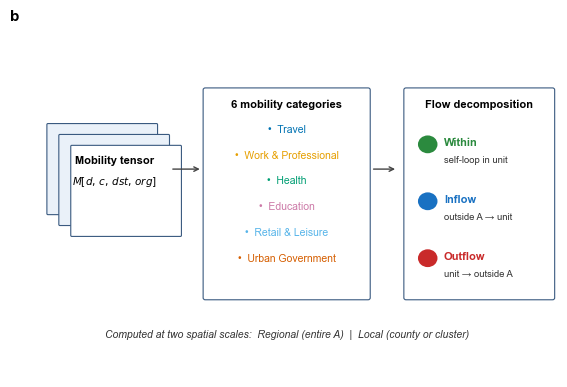

In [6]:
def panel_b_schematic(ax):
    """Decorative schematic: tensor → categories → flow decomposition."""
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 7)
    ax.set_aspect('auto')
    ax.axis('off')

    # ── Block 1: mobility tensor (stacked rectangles) ──
    tx, ty = 1.6, 4.2
    for i, dz in enumerate([0.0, 0.22, 0.44]):
        rect = FancyBboxPatch((tx - 1.0 + dz, ty - 0.9 - dz),
                              2.0, 1.8,
                              boxstyle='round,pad=0.02',
                              facecolor='#eaf1f9' if i < 2 else 'white',
                              edgecolor='#3a5a80', linewidth=0.8, zorder=i)
        ax.add_patch(rect)
    ax.text(tx + 0.22, ty + 0.18, 'Mobility tensor',
            ha='center', va='center', fontsize=8, fontweight='bold', zorder=10)
    ax.text(tx + 0.22, ty - 0.25, r'$M[d,\,c,\,dst,\,org]$',
            ha='center', va='center', fontsize=7.5, zorder=10)

    # Arrow → categories
    ax.annotate('', xy=(3.45, 4.2), xytext=(2.85, 4.2),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.0))

    # ── Block 2: 6 categories ──
    cx = 5.0
    cat_box = FancyBboxPatch((cx - 1.5, 1.6), 3.0, 4.2,
                             boxstyle='round,pad=0.04',
                             facecolor='white', edgecolor='#3a5a80', linewidth=0.8)
    ax.add_patch(cat_box)
    ax.text(cx, 5.5, '6 mobility categories', ha='center', va='center',
            fontsize=8, fontweight='bold')
    for i, cat in enumerate(CATEGORIES):
        ax.text(cx, 5.0 - i * 0.52, '\u2022  ' + cat,
                ha='center', va='center', fontsize=7.5,
                color=CATEGORY_COLORS[cat])

    # Arrow → flows
    ax.annotate('', xy=(7.05, 4.2), xytext=(6.55, 4.2),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.0))

    # ── Block 3: flow decomposition ──
    fx = 8.55
    flow_box = FancyBboxPatch((fx - 1.35, 1.6), 2.7, 4.2,
                              boxstyle='round,pad=0.04',
                              facecolor='white', edgecolor='#3a5a80', linewidth=0.8)
    ax.add_patch(flow_box)
    ax.text(fx, 5.5, 'Flow decomposition', ha='center', va='center',
            fontsize=8, fontweight='bold')
    flow_specs = [
        ('Within',  '#2b8a3e', 'self-loop in unit'),
        ('Inflow',  '#1971c2', 'outside A \u2192 unit'),
        ('Outflow', '#c92a2a', 'unit \u2192 outside A'),
    ]
    for i, (name, col, desc) in enumerate(flow_specs):
        y = 4.7 - i * 1.15
        ax.add_patch(mpatches.Circle((fx - 0.95, y), 0.18,
                                     facecolor=col, edgecolor='none'))
        ax.text(fx - 0.65, y + 0.04, name, ha='left', va='center',
                fontsize=8, fontweight='bold', color=col)
        ax.text(fx - 0.65, y - 0.32, desc, ha='left', va='center',
                fontsize=6.8, color='#333')

    # Footer: spatial scales
    ax.text(5.0, 0.85,
            'Computed at two spatial scales:  Regional (entire A)  |  Local (county or cluster)',
            ha='center', va='center', fontsize=7.5, style='italic', color='#333')

    ax.text(-0.01, 1.02, 'b', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='bottom', ha='left')


# Render and save panel (b) as its own file
fig_b, ax_b = plt.subplots(figsize=(7.0, 4.5))
panel_b_schematic(ax_b)
save_panel(fig_b, 'figure1b_schematic')
plt.show()

## Panel (c) — Worked example time series

Pulls observed mobility (`y_true`), SARIMAX baseline (`y_pred`), and 95% CI from the cached `baseline_{flow}_{Category}.csv`; pulls trough date, recovery date, largest drop, and recovery days from `regional_metrics_summary.csv`. No re-fitting.

Saves `figure1c_worked_example.{pdf,png}`. To swap the example, edit the `EXAMPLE` dict in the configuration cell.

  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure1c_worked_example.pdf
  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure1c_worked_example.png


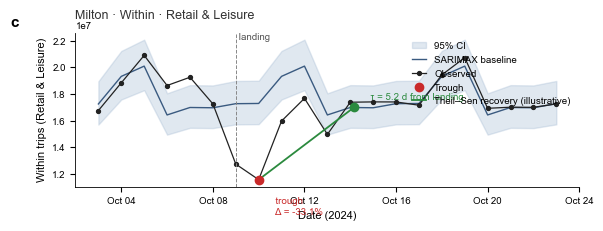

In [11]:
def panel_c_worked_example(ax):
    hkey = EXAMPLE['hurricane']
    flow = EXAMPLE['flow_type']
    cat  = EXAMPLE['category']
    cat_safe = category_to_filename(cat)

    bl_path = RESULTS / 'regional_level' / hkey / f'baseline_{flow}_{cat_safe}.csv'
    bl = pd.read_csv(bl_path, index_col=0, parse_dates=True)

    metrics = pd.read_csv(RESULTS / 'regional_level' / 'regional_metrics_summary.csv')
    row = metrics[(metrics['hurricane'] == hkey)
                  & (metrics['flow_type'] == flow)
                  & (metrics['category']  == cat)].iloc[0]

    landing       = HURRICANES[hkey]['landing']
    trough_date   = pd.to_datetime(row['trough_date']).normalize()
    recovery_date = pd.to_datetime(row['recovery_date'])
    drop_pct      = row['largest_drop']
    recovery_days = row['recovery_days']

    win_start = landing - pd.Timedelta(days=10)
    win_end   = landing + pd.Timedelta(days=14)
    bl_w = bl.loc[win_start:win_end]

    # CI envelope
    ax.fill_between(bl_w.index, bl_w['ci_lower'], bl_w['ci_upper'],
                    color='#9bb4cf', alpha=0.30, label='95% CI')
    # Baseline line
    ax.plot(bl_w.index, bl_w['y_pred'], color='#3a5a80', linewidth=1.0,
            label='SARIMAX baseline')
    # Observed
    ax.plot(bl_w.index, bl_w['y_true'], color='#222222', linewidth=0.9,
            marker='o', markersize=2.8, label='Observed')

    # Landing vertical line
    ax.axvline(landing, color='#888888', linestyle='--', linewidth=0.7)
    ymin, ymax = ax.get_ylim()
    ax.text(landing, ymax, ' landing', ha='left', va='top',
            fontsize=7, color='#555')

    # Trough marker
    if trough_date in bl_w.index:
        trough_val = bl_w.loc[trough_date, 'y_true']
    else:
        nearest = bl_w.index[bl_w.index.get_indexer([trough_date], method='nearest')[0]]
        trough_val = bl_w.loc[nearest, 'y_true']
        trough_date = nearest
    ax.scatter([trough_date], [trough_val], s=36, color='#c92a2a',
               zorder=5, label='Trough')
    ax.annotate(f'  trough\n  \u0394 = {drop_pct:.1f}%',
                xy=(trough_date, trough_val),
                xytext=(8, -25), textcoords='offset points',
                fontsize=7, color='#c92a2a')

    # Recovery illustration: line from trough to baseline at recovery_date
    if pd.notna(recovery_date):
        rec_anchor = bl.index.asof(recovery_date)
        rec_val = bl.loc[rec_anchor, 'y_pred']
        ax.plot([trough_date, recovery_date], [trough_val, rec_val],
                color='#2b8a3e', linestyle='-', linewidth=1.3,
                label='Theil\u2013Sen recovery (illustrative)')
        ax.scatter([recovery_date], [rec_val], s=36, color='#2b8a3e', zorder=5)
        ax.annotate(f'  \u03c4 = {recovery_days:.1f} d from landing',
                    xy=(recovery_date, rec_val),
                    xytext=(8, 6), textcoords='offset points',
                    fontsize=7, color='#2b8a3e')

    ax.set_xlabel('Date (2024)')
    ax.set_ylabel(f'{flow.capitalize()} trips ({cat})')
    ax.legend(loc='upper right', frameon=False, fontsize=7, ncol=1, handlelength=1.5)

    ax.xaxis.set_major_locator(DayLocator(interval=4))
    ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
    plt.setp(ax.get_xticklabels(), rotation=0)

    ax.text(-0.13, 1.02, 'c', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='bottom', ha='left')
    ax.set_title(f"{HURRICANES[hkey]['label']} \u00b7 {flow.capitalize()} \u00b7 {cat}",
                 loc='left', fontsize=9, color='#333', pad=2)


# Render and save panel (c) as its own file
fig_c, ax_c = plt.subplots(figsize=(6.5, 2.0))
panel_c_worked_example(ax_c)
save_panel(fig_c, 'figure1c_worked_example')
plt.show()

### Caption draft (for use when you assemble the combined Fig. 1)

**Fig. 1 | Study setup and analysis framework.**
**(a)** Counties affected by Hurricane Helene (blue, *n* = 271, landfall 2024-09-26) and Hurricane Milton (red, *n* = 21, landfall 2024-10-09), defined as counties whose centroid falls within 50 mi of the official storm track. Dotted lines show the 50-mile cutoff envelope; solid lines show the storm tracks.
**(b)** Analytical pipeline. The 4-D mobility tensor *M*[*d*, *c*, *dst*, *org*] is filtered to six urban-functional categories (Utilities excluded) and decomposed into within-region, inflow, and outflow trips at two spatial scales — regional (entire affected area *A*) and local (county or cluster).
**(c)** Worked example for the selected category. Observed trips (black) deviate from the SARIMAX counterfactual baseline (navy line, 95% CI in light blue) following landfall. The trough (red) marks peak disruption (Δ). Recovery time τ is measured from landfall to the Theil–Sen recovery-line zero-crossing (green).

*Update Δ and τ values in the caption to match whichever `EXAMPLE` is rendered.*